In [ ]:
from tqdm.auto import tqdm
tqdm.pandas()

import altair as alt
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns

from utils import load_and_process_dasm_data, GERMLINE_PATH_DICTIONARY, sort_antibody_sites, add_cdr_shading


In [ ]:

old_model_name = "dasm"
new_model_name = "../trained_models_no_multihit/dasm_4m-v1jaffeCC+v1tangCC-joint"
new_model_name2 = "../trained_models_multihit_from_scratch/dasm_4m-v1jaffeCC+v1tangCC-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'


old_site_sub_probs_df, old_pcp_df, old_aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=old_model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)

new_site_sub_probs_df, new_pcp_df, new_aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=new_model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)

new_mutlihit_site_sub_probs_df, new_multihit_pcp_df, new_multihit_aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=new_model_name2,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)

Adding one_mutation_away column (vectorized)...
Adding one_mutation_away column (vectorized)...


In [29]:
new_model_name2 = "../trained_models_multihit_from_scratch/dasm_4m-v1jaffeCC+v1tangCC-joint"


new_mutlihit_site_sub_probs_df, new_multihit_pcp_df, new_multihit_aa_site_subs_selection_df_germline = load_and_process_dasm_data(
    model_name=new_model_name2,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)

Adding one_mutation_away column (vectorized)...


Regression equation: y = 0.8848x + 0.1588
Pearson correlation: r = 0.8751, p-value = 0.00e+00


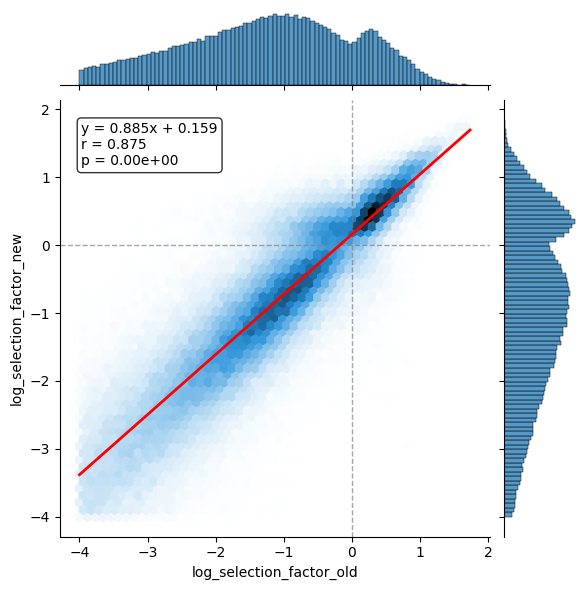

In [27]:
## let's sample the same 100 pcp indices from both datasets and compare the selection factors
sampled_pcp_indices = np.random.choice(old_aa_site_subs_selection_df_germline['pcp_index'].unique(), size=100, replace=False)
comparison_df = pd.merge(
    old_aa_site_subs_selection_df_germline[
        old_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    new_aa_site_subs_selection_df_germline[
        new_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    on=['pcp_index', 'site', 'selection_factor_target_aa',
       'is_cdr', 'parent_codon', 'parent_aa', 'child_codon',
       'child_aa', 'sample_id', 'family', 
       'v_gene', 'j_gene', 'v_family',
       'germline_codon', 'germline_amino_acid', 'is_germline_aa',
       'is_germline_codon', 'one_mutation_away'],
    suffixes=('_old', '_new')
)

from scipy.stats import pearsonr
from scipy.stats import linregress

comparison_df['log_selection_factor_new'] = comparison_df['log_selection_factor_new'].clip(lower=-4)
comparison_df['log_selection_factor_old'] = comparison_df['log_selection_factor_old'].clip(lower=-4)

# Filter the data
filtered_df = comparison_df[(comparison_df['log_selection_factor_old'] > -4) & 
                            (comparison_df['log_selection_factor_new'] > -4)]

# Calculate Pearson correlation
r, p_value = pearsonr(filtered_df['log_selection_factor_old'], 
                      filtered_df['log_selection_factor_new'])

# Calculate regression line
slope, intercept, r_value, p_value_reg, std_err = linregress(
    filtered_df['log_selection_factor_old'], 
    filtered_df['log_selection_factor_new']
)

# Create the plot
g = sns.jointplot(filtered_df, 
                  x='log_selection_factor_old', 
                  y='log_selection_factor_new', 
                  kind='hex')

# Add x=0 and y=0 reference lines
g.ax_joint.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add regression line
x_reg = filtered_df['log_selection_factor_old']
y_reg = slope * x_reg + intercept
g.ax_joint.plot(x_reg.sort_values(), 
                slope * x_reg.sort_values() + intercept, 
                'r-', linewidth=2, label='Regression line')

# Add correlation and equation annotation to the plot
equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nr = {r:.3f}\np = {p_value:.2e}'
g.ax_joint.text(0.05, 0.95, equation_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

print(f"Regression equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"Pearson correlation: r = {r:.4f}, p-value = {p_value:.2e}")

Regression equation: y = 0.8581x + -0.2203
Pearson correlation: r = 0.8615, p-value = 0.00e+00


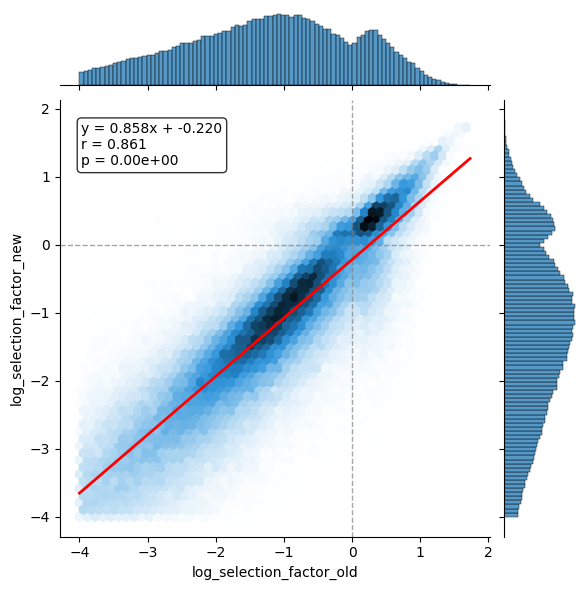

In [30]:
## let's sample the same 100 pcp indices from both datasets and compare the selection factors
sampled_pcp_indices = np.random.choice(old_aa_site_subs_selection_df_germline['pcp_index'].unique(), size=100, replace=False)
comparison_df = pd.merge(
    old_aa_site_subs_selection_df_germline[
        old_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    new_multihit_aa_site_subs_selection_df_germline[
        new_multihit_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    on=['pcp_index', 'site', 'selection_factor_target_aa',
       'is_cdr', 'parent_codon', 'parent_aa', 'child_codon',
       'child_aa', 'sample_id', 'family', 
       'v_gene', 'j_gene', 'v_family',
       'germline_codon', 'germline_amino_acid', 'is_germline_aa',
       'is_germline_codon', 'one_mutation_away'],
    suffixes=('_old', '_new')
)

from scipy.stats import pearsonr
from scipy.stats import linregress

comparison_df['log_selection_factor_new'] = comparison_df['log_selection_factor_new'].clip(lower=-4)
comparison_df['log_selection_factor_old'] = comparison_df['log_selection_factor_old'].clip(lower=-4)

# Filter the data
filtered_df = comparison_df[(comparison_df['log_selection_factor_old'] > -4) & 
                            (comparison_df['log_selection_factor_new'] > -4)]

# Calculate Pearson correlation
r, p_value = pearsonr(filtered_df['log_selection_factor_old'], 
                      filtered_df['log_selection_factor_new'])

# Calculate regression line
slope, intercept, r_value, p_value_reg, std_err = linregress(
    filtered_df['log_selection_factor_old'], 
    filtered_df['log_selection_factor_new']
)

# Create the plot
g = sns.jointplot(filtered_df, 
                  x='log_selection_factor_old', 
                  y='log_selection_factor_new', 
                  kind='hex')

# Add x=0 and y=0 reference lines
g.ax_joint.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add regression line
x_reg = filtered_df['log_selection_factor_old']
y_reg = slope * x_reg + intercept
g.ax_joint.plot(x_reg.sort_values(), 
                slope * x_reg.sort_values() + intercept, 
                'r-', linewidth=2, label='Regression line')

# Add correlation and equation annotation to the plot
equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nr = {r:.3f}\np = {p_value:.2e}'
g.ax_joint.text(0.05, 0.95, equation_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

print(f"Regression equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"Pearson correlation: r = {r:.4f}, p-value = {p_value:.2e}")

Regression equation: y = 0.8395x + -0.4865
Pearson correlation: r = 0.8503, p-value = 0.00e+00


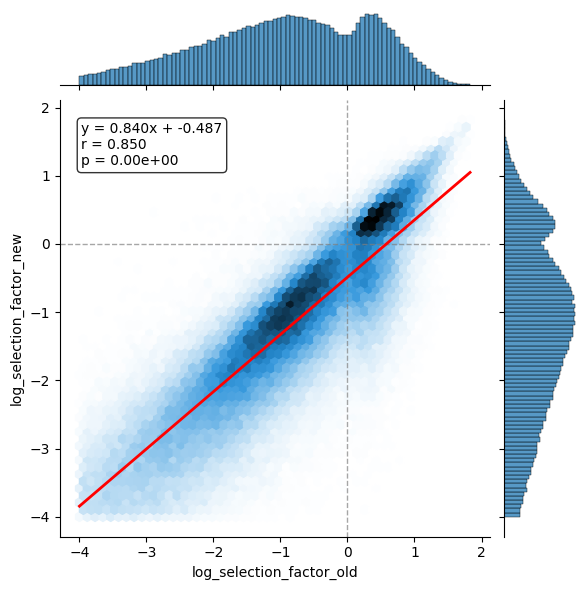

In [32]:
## let's sample the same 100 pcp indices from both datasets and compare the selection factors
sampled_pcp_indices = np.random.choice(old_aa_site_subs_selection_df_germline['pcp_index'].unique(), size=100, replace=False)
comparison_df = pd.merge(
    new_aa_site_subs_selection_df_germline[
        new_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    new_multihit_aa_site_subs_selection_df_germline[
        new_multihit_aa_site_subs_selection_df_germline['pcp_index'].isin(sampled_pcp_indices)
    ],
    on=['pcp_index', 'site', 'selection_factor_target_aa',
       'is_cdr', 'parent_codon', 'parent_aa', 'child_codon',
       'child_aa', 'sample_id', 'family', 
       'v_gene', 'j_gene', 'v_family',
       'germline_codon', 'germline_amino_acid', 'is_germline_aa',
       'is_germline_codon', 'one_mutation_away'],
    suffixes=('_old', '_new')
)

from scipy.stats import pearsonr
from scipy.stats import linregress

comparison_df['log_selection_factor_new'] = comparison_df['log_selection_factor_new'].clip(lower=-4)
comparison_df['log_selection_factor_old'] = comparison_df['log_selection_factor_old'].clip(lower=-4)

# Filter the data
filtered_df = comparison_df[(comparison_df['log_selection_factor_old'] > -4) & 
                            (comparison_df['log_selection_factor_new'] > -4)]

# Calculate Pearson correlation
r, p_value = pearsonr(filtered_df['log_selection_factor_old'], 
                      filtered_df['log_selection_factor_new'])

# Calculate regression line
slope, intercept, r_value, p_value_reg, std_err = linregress(
    filtered_df['log_selection_factor_old'], 
    filtered_df['log_selection_factor_new']
)

# Create the plot
g = sns.jointplot(filtered_df, 
                  x='log_selection_factor_old', 
                  y='log_selection_factor_new', 
                  kind='hex')

# Add x=0 and y=0 reference lines
g.ax_joint.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
g.ax_joint.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Add regression line
x_reg = filtered_df['log_selection_factor_old']
y_reg = slope * x_reg + intercept
g.ax_joint.plot(x_reg.sort_values(), 
                slope * x_reg.sort_values() + intercept, 
                'r-', linewidth=2, label='Regression line')

# Add correlation and equation annotation to the plot
equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nr = {r:.3f}\np = {p_value:.2e}'
g.ax_joint.text(0.05, 0.95, equation_text,
                transform=g.ax_joint.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

print(f"Regression equation: y = {slope:.4f}x + {intercept:.4f}")
print(f"Pearson correlation: r = {r:.4f}, p-value = {p_value:.2e}")